<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/Hands_On_Week_5_Statistika_Deskriptif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Week 5 — Descriptive Statistics & Summaries  
## Fokus: Measures of Location, Dispersion, Five-Number Summary, Skewness, dan Kurtosis


## Alur praktikum

Pada praktikum ini, akan mempelajari statistika deskriptif secara **bertahap, terurut, dan sistematis**. Fokus utama praktikum adalah memahami bagaimana data diringkas sehingga lebih mudah dibaca, dibandingkan, dan diinterpretasikan.

Urutan pembelajaran:
1. Mengunggah dan membaca data `happiness_dataset.csv`
2. Mengenal dataset secara singkat
3. Menyiapkan data untuk analisis
4. Melihat gambaran umum statistika deskriptif
5. Menghitung **measures of location** (mean, median, mode)
6. Menghitung **measures of dispersion** (range, variance, standard deviation, IQR)
7. Memahami **measures of position** (quartile dan five-number summary)
8. Memahami **shape of distribution** melalui **skewness** dan **kurtosis**
9. Menemukan outlier dengan aturan **1.5 × IQR**
10. Membuat visualisasi sederhana untuk membantu interpretasi
11. Menulis interpretasi hasil secara ringkas dan benar


## Pengetahuan prasyarat
- konsep data dan variabel
- perbedaan data numerik dan kategorik
- penggunaan dasar `pandas` seperti `read_csv()` dan `head()`

## 1. Import library
Library yang digunakan:
- `pandas` untuk membaca dan mengolah data tabel
- `numpy` untuk perhitungan numerik
- `matplotlib` dan `seaborn` untuk visualisasi

Jalankan cell berikut terlebih dahulu.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

## 2. Upload file `happiness_dataset.csv` langsung dari komputer
- Klik tombol **Choose Files**
- Pilih file **`happiness_dataset.csv`** dari komputer (drive penyimpanan file)


In [ ]:
# Upload file dari komputer (khusus Google Colab)
try:
    from google.colab import files
    uploaded = files.upload()
    print("File yang berhasil diupload:", list(uploaded.keys()))
except Exception as e:
    print("Mode non-Colab atau upload dilewati.")
    print("Pesan:", e)

Saving happiness_dataset.csv to happiness_dataset (1).csv
File yang berhasil diupload: ['happiness_dataset (1).csv']


## 3. Membaca file CSV
Bagian ini menggunakan `pandas.read_csv()`.

In [ ]:
from pathlib import Path

possible_paths = [
    Path("/content/happiness_dataset.csv"),   # umum di Colab
    Path("happiness_dataset.csv"),            # jika berada di folder kerja aktif
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError(
        "File happiness_dataset.csv belum ditemukan. "
        "Silakan upload dulu file dari komputer Anda."
    )

df = pd.read_csv(csv_path)
print("File dibaca dari:", csv_path)
print("Ukuran data:", df.shape)
df.head()

File dibaca dari: /content/happiness_dataset.csv
Ukuran data: (153, 12)


,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,Western Europe


## 4. Mengenal dataset secara singkat
Dataset ini berisi data kebahagiaan beberapa negara di dunia.  
Setiap baris merepresentasikan **satu negara**, dan setiap kolom berisi skor atau informasi yang berkaitan dengan kebahagiaan.

### Ringkasan awal dataset
- Jumlah baris: **153**
- Jumlah kolom: **12**
- Kolom numerik utama mencakup peringkat, skor kebahagiaan, ekonomi, keluarga, kesehatan, kebebasan, kemurahan hati, korupsi, dan kepuasan kerja.
- Terdapat juga kolom kategorik seperti **negara** dan **region**.

### Mengapa dataset ini cocok untuk Week 5?
Karena dataset ini punya beberapa variabel numerik yang mudah dianalisis dengan:
- mean
- median
- mode
- range
- variance
- standard deviation
- IQR
- five-number summary

### Mengapa menggunakan dataset ini?
- memiliki beberapa **variabel numerik** yang bisa dihitung mean, median, SD, dan IQR
- memiliki **variabel kategorik** seperti negara atau region yang bisa dipakai untuk ringkasan per kelompok
- konteksnya mudah dipahami mahasiswa karena berkaitan dengan kondisi kesejahteraan/kebahagiaan suatu negara

### Tampilkan beberapa baris data
- Jumlah baris yang ditampilkan adalah 10 baris.
- Perhatikan setiap nama kolom, jenis informasi, dan bentuk datanya.

In [ ]:
df.head(10)

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,Western Europe
5,Netherlands,6,7.377,1.503945,1.428939,0.810696,0.585384,0.470490,0.282662,2.294804,93.8,Western Europe
6,Canada,7,7.316,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264,90.5,North America
7,New Zealand,8,7.314,1.405706,1.548195,0.816760,0.614062,0.500005,0.382817,2.046456,88.6,Asia-Pacific
8,Sweden,9,7.284,1.494387,1.478162,0.830875,0.612924,0.385399,0.384399,2.097538,92.7,Western Europe
9,Australia,10,7.284,1.484415,1.510042,0.843887,0.601607,0.477699,0.301184,2.065211,89.2,Asia-Pacific


### Lihat nama kolom
Langkah ini untuk mengetahui variabel apa saja yang tersedia.

In [ ]:
list(df.columns)

['Country',
 'Happiness Rank',
 'Happiness Score',
 'Economy',
 'Family',
 'Health',
 'Freedom',
 'Generosity',
 'Corruption',
 'Dystopia',
 'Job Satisfaction',
 'Region']

### Lihat tipe data
- **numerik** → bisa dihitung mean, median, SD, dan sebagainya
- **kategorik (kualitatif)** → biasanya diringkas dengan frekuensi atau proporsi

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           153 non-null    object 
 1   Happiness Rank    153 non-null    int64  
 2   Happiness Score   153 non-null    float64
 3   Economy           153 non-null    float64
 4   Family            153 non-null    float64
 5   Health            153 non-null    float64
 6   Freedom           153 non-null    float64
 7   Generosity        153 non-null    float64
 8   Corruption        153 non-null    float64
 9   Dystopia          153 non-null    float64
 10  Job Satisfaction  151 non-null    float64
 11  Region            153 non-null    object 
dtypes: float64(9), int64(1), object(2)
memory usage: 14.5+ KB


## 5. Pembersihan data sederhana
Untuk analisis statistik deskriptif, perlu dilakukan pembersihan data:
1. rapikan nama kolom
2. pastikan kolom numerik benar-benar bertipe numerik
3. cek missing values

In [ ]:
df = df.copy()

# Rapikan nama kolom: huruf kecil dan spasi menjadi underscore
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df.head()

,country,happiness_rank,happiness_score,economy,family,health,freedom,generosity,corruption,dystopia,job_satisfaction,region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,Western Europe


### Cek missing values
Missing value adalah data yang kosong atau tidak terisi.  
Sebelum menghitung nilai statistik, perlu mengetahui apakah ada nilai yang hilang.

In [ ]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values("missing_count", ascending=False)

missing_table

,missing_count,missing_percent
job_satisfaction,2,1.31
country,0,0.00
happiness_score,0,0.00
happiness_rank,0,0.00
economy,0,0.00
family,0,0.00
freedom,0,0.00
health,0,0.00
generosity,0,0.00
corruption,0,0.00


### Tentukan kolom numerik dan kolom kategorik
Ini membantu untuk membedakan variabel yang bisa dihitung statistiknya.

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print("Kolom numerik:")
for col in numeric_cols:
    print("-", col)

print("\nKolom kategorik:")
for col in categorical_cols:
    print("-", col)

Kolom numerik:
- happiness_rank
- happiness_score
- economy
- family
- health
- freedom
- generosity
- corruption
- dystopia
- job_satisfaction

Kolom kategorik:
- country
- region


## 6. Memilih variabel utama untuk dianalisis
Pada notebook ini, kita gunakan **`happiness_score`** sebagai variabel utama.  
Alasannya:
- variabel ini paling langsung menggambarkan tingkat kebahagiaan
- mudah diinterpretasikan
- cocok untuk menjelaskan ukuran pemusatan dan penyebaran

Jika kolom tersebut tidak ditemukan, notebook akan memilih kolom numerik pertama sebagai cadangan.

In [ ]:
target = "happiness_score" if "happiness_score" in df.columns else numeric_cols[0]
x = df[target].dropna()

print("Variabel utama yang dipakai:", target)
print("Jumlah data valid:", len(x))

Variabel utama yang dipakai: happiness_score
Jumlah data valid: 153


## 7. Descriptive statistics: gambaran umum

Sebelum masuk ke perhitungan satu per satu, kita lihat dulu ringkasan umum variabel numerik.  
Ringkasan ini biasanya menampilkan:
- jumlah data (`count`)
- rata-rata (`mean`)
- simpangan baku (`std`)
- nilai minimum (`min`)
- kuartil 1 (`25%`)
- median (`50%`)
- kuartil 3 (`75%`)
- nilai maksimum (`max`)

Bagian ini penting karena memberi **gambaran cepat** tentang pusat data, penyebaran data, dan posisi data.


In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
happiness_rank,153.0,78.169935,45.008741,1.000000,40.000000,78.000000,117.000000,155.000000
happiness_score,153.0,5.349281,1.134997,2.693000,4.497000,5.279000,6.098000,7.537000
economy,153.0,0.982433,0.421901,0.000000,0.659517,1.064578,1.315175,1.870766
family,153.0,1.186630,0.288441,0.000000,1.041990,1.251826,1.416404,1.610574
health,153.0,0.550117,0.237769,0.000000,0.364509,0.606042,0.719217,0.949492
freedom,153.0,0.408489,0.150744,0.000000,0.300741,0.437454,0.518631,0.658249
generosity,153.0,0.245324,0.134395,0.000000,0.153075,0.231503,0.322228,0.838075
corruption,153.0,0.123179,0.102133,0.000000,0.057070,0.089848,0.153066,0.464308
dystopia,153.0,1.853072,0.499490,0.377914,1.597970,1.832910,2.150801,3.117485
job_satisfaction,151.0,75.209934,12.962365,44.400000,68.950000,78.100000,85.100000,95.100000


### Catatan penting

Output `describe()` sangat berguna sebagai langkah awal, tetapi belum cukup untuk memahami data secara lengkap.  
Agar pembacaan data lebih baik, masih diperlukan informasi statistik meliputi:
- **mode** → nilai yang paling sering muncul
- **IQR** → penyebaran 50% data tengah
- **skewness** → arah kemencengan distribusi
- **kurtosis** → bentuk puncak dan ekor distribusi
- **outlier** → nilai yang jauh dari pola umum

Karena itu, setelah bagian ini kita akan menghitung ukuran-ukuran tersebut satu per satu.


# Bagian A — Measures of Location
Ukuran lokasi atau ukuran pemusatan bertujuan menjawab pertanyaan:

> **"Di sekitar nilai berapa data cenderung berkumpul?"**

Tiga ukuran yang paling umum:
1. **Mean**: rata-rata
2. **Median**: nilai tengah
3. **Mode**: nilai yang paling sering muncul

## A1. Mean
### Pengertian
Mean adalah jumlah seluruh nilai dibagi banyaknya data.

### Kapan mean berguna?
Mean cocok digunakan jika distribusi data cukup seimbang dan tidak terlalu dipengaruhi outlier.

### Catatan
Mean **sensitif terhadap nilai ekstrem**.

In [ ]:
mean_value = x.mean()
print(f"Mean {target} = {mean_value:.4f}")

Mean happiness_score = 5.3493


## A2. Median
### Pengertian
Median adalah **nilai tengah** setelah data diurutkan.

### Kelebihan median
Median lebih tahan terhadap outlier dibanding mean.

### Intuisi sederhana
Jika data diurutkan dari kecil ke besar, median berada di posisi tengah.

In [ ]:
median_value = x.median()
print(f"Median {target} = {median_value:.4f}")

Median happiness_score = 5.2790


## A3. Mode
### Pengertian
Mode adalah nilai yang paling sering muncul.

### Catatan penting
- Pada data kontinu, mode kadang kurang informatif karena banyak nilai bisa unik.

In [ ]:
mode_values = x.mode()

print("Mode:")
print(mode_values)

if len(mode_values) > 0:
    print(f"Mode pertama = {mode_values.iloc[0]:.4f}")

Mode:
0    5.074
1    5.838
2    6.454
3    7.284
Name: happiness_score, dtype: float64
Mode pertama = 5.0740


## A4. Bandingkan mean, median, dan mode
Perbandingan tiga ukuran ini membantu kita memahami bentuk data.

### Petunjuk interpretasi
- Jika **mean ≈ median**, distribusi cenderung cukup simetris.
- Jika **mean > median**, distribusi sering cenderung miring ke kanan (*right-skewed*).
- Jika **mean < median**, distribusi sering cenderung miring ke kiri (*left-skewed*).

## Checkpoint pemahaman 1
Sebelum lanjut, jawab singkat:
1. Mengapa mean dan median bisa berbeda?
2. Dalam kondisi apa median lebih baik digunakan daripada mean?
3. Jika mode tidak terlalu informatif pada data kontinu, mengapa tetap penting dipelajari?

In [ ]:
summary_location = pd.DataFrame({
    "statistic": ["mean", "median", "mode_pertama"],
    "value": [mean_value, median_value, mode_values.iloc[0] if len(mode_values) > 0 else np.nan]
})

summary_location

,statistic,value
0,mean,5.349281
1,median,5.279000
2,mode_pertama,5.074000


# Bagian B — Measures of Dispersion


## B1. Range
### Pengertian
Range adalah selisih antara nilai maksimum dan minimum.

### Kelemahan
Range sangat dipengaruhi oleh nilai ekstrem.

In [ ]:
range_value = x.max() - x.min()
print(f"Range {target} = {range_value:.4f}")

Range happiness_score = 4.8440


## B2. Variance
### Pengertian
Variance mengukur rata-rata kuadrat penyimpangan data dari mean.

### Catatan
Karena memakai kuadrat, satuan variance menjadi **kuadrat dari satuan asli**, sehingga kadang kurang mudah ditafsirkan langsung.

In [ ]:
variance_value = x.var(ddof=1)   # sample variance
print(f"Sample variance {target} = {variance_value:.4f}")

Sample variance happiness_score = 1.2882


## B3. Standard deviation
### Pengertian
Standard deviation (simpangan baku) adalah akar kuadrat dari variance.

### Mengapa penting?
Karena kembali ke satuan asal data, standard deviation lebih mudah ditafsirkan dibanding variance.

In [ ]:
std_value = x.std(ddof=1)   # sample standard deviation
print(f"Sample standard deviation {target} = {std_value:.4f}")

Sample standard deviation happiness_score = 1.1350


## B4. Quartile dan IQR
### Apa itu kuartil?
Kuartil membagi data yang sudah diurutkan menjadi empat bagian:
- **Q1**: 25% data berada di bawah nilai ini
- **Q2**: median
- **Q3**: 75% data berada di bawah nilai ini

### IQR
IQR (*Interquartile Range*) adalah:
\[
IQR = Q3 - Q1
\]

IQR menggambarkan lebar penyebaran **50% data tengah** dan lebih tahan terhadap outlier.

In [ ]:
q1 = x.quantile(0.25)
q2 = x.quantile(0.50)
q3 = x.quantile(0.75)
iqr_value = q3 - q1

print(f"Q1  = {q1:.4f}")
print(f"Q2  = {q2:.4f}")
print(f"Q3  = {q3:.4f}")
print(f"IQR = {iqr_value:.4f}")

Q1  = 4.4970
Q2  = 5.2790
Q3  = 6.0980
IQR = 1.6010


## B5. Koefisien variasi (coefficient of variation)

Koefisien variasi atau **CV** menunjukkan besar penyebaran data **dibandingkan dengan rata-ratanya**.  
Rumus sederhananya:

Interpretasi umum:
- CV kecil → data relatif lebih homogen
- CV besar → data relatif lebih bervariasi

Catatan: CV paling cocok digunakan jika mean tidak bernilai 0 dan data berada pada skala rasio.


## B6. Ringkasan ukuran penyebaran


In [ ]:
cv_value = (std_value / mean_value) * 100 if mean_value != 0 else np.nan

summary_dispersion = pd.DataFrame({
    "Ukuran": ["Range", "Variance", "Standard Deviation", "IQR", "Coefficient of Variation (%)"],
    "Nilai": [range_value, variance_value, std_value, iqr_value, cv_value]
})
summary_dispersion


,Ukuran,Nilai
0,Range,4.844000
1,Variance,1.288219
2,Standard Deviation,1.134997
3,IQR,1.601000
4,Coefficient of Variation (%),21.217754


## Checkpoint pemahaman 2

Diskusikan bersama:
1. Apa perbedaan **variance** dan **standard deviation**?
2. Mengapa **IQR** sering dipakai saat data memiliki outlier?
3. Kapan **coefficient of variation** berguna untuk membandingkan dua kelompok data?


# Bagian C — Measures of Position dan Five-Number Summary


## C1. Quartile sebagai ukuran letak

Kuartil membagi data yang sudah diurutkan menjadi empat bagian:
- **Q1**: batas 25% data terbawah
- **Q2**: median atau 50%
- **Q3**: batas 75% data terbawah

Kuartil membantu kita memahami **di mana posisi data berada**, bukan hanya seberapa besar pusat dan penyebarannya.


## C2. Five-number summary

Five-number summary terdiri dari lima angka penting:
1. minimum
2. kuartil 1 (Q1)
3. median
4. kuartil 3 (Q3)
5. maksimum

Ringkasan ini sangat penting karena menjadi dasar untuk membaca **boxplot** dan mendeteksi **outlier**.


## C3. Menghitung five-number summary


In [ ]:
five_number_summary = pd.DataFrame({
    "component": ["minimum", "Q1", "median", "Q3", "maximum"],
    "value": [x.min(), q1, median_value, q3, x.max()]
})

five_number_summary

,component,value
0,minimum,2.693
1,Q1,4.497
2,median,5.279
3,Q3,6.098
4,maximum,7.537


## D1. Skewness

**Skewness** menunjukkan arah dan tingkat kemencengan distribusi data.

Interpretasi sederhana:
- skewness ≈ 0 → distribusi relatif simetris
- skewness > 0 → distribusi menceng ke kanan
- skewness < 0 → distribusi menceng ke kiri

Panduan praktis:
- antara -0.5 sampai 0.5 → hampir simetris
- antara 0.5 sampai 1 atau -0.5 sampai -1 → kemencengan sedang
- lebih dari 1 atau kurang dari -1 → kemencengan kuat


In [ ]:
skewness_value = x.skew()
print(f"Skewness {target}: {skewness_value:.4f}")


Skewness happiness_score: 0.0169


## D2. Kurtosis

**Kurtosis** membantu melihat apakah distribusi memiliki ekor yang ringan atau berat, serta apakah ada kecenderungan nilai ekstrem.

Di pandas, nilai kurtosis yang dihitung adalah **excess kurtosis**, sehingga:
- kurtosis ≈ 0 → mirip distribusi normal
- kurtosis > 0 → puncak lebih runcing / ekor lebih berat
- kurtosis < 0 → puncak lebih datar / ekor lebih ringan


In [ ]:
kurtosis_value = x.kurt()
print(f"Kurtosis {target}: {kurtosis_value:.4f}")


Kurtosis happiness_score: -0.7558


## D3. Ringkasan bentuk distribusi

Ringkasan ini membantu kita membaca distribusi dengan lebih lengkap:
- mean, median, dan mode → pusat data
- standard deviation dan IQR → penyebaran data
- skewness → arah kemencengan
- kurtosis → bentuk puncak dan ekor distribusi


In [ ]:
shape_summary = pd.DataFrame({
    "Ukuran": ["Skewness", "Kurtosis"],
    "Nilai": [skewness_value, kurtosis_value]
})
shape_summary


,Ukuran,Nilai
0,Skewness,0.016906
1,Kurtosis,-0.755792


## Checkpoint pemahaman 3

Diskusikan bersama:
1. Jika mean lebih besar daripada median, distribusi cenderung menceng ke arah mana?
2. Mengapa skewness dan kurtosis perlu dibaca bersama histogram dan boxplot?
3. Apakah kurtosis tinggi selalu berarti data buruk? Jelaskan.


# Bagian E — Outlier

Setelah mengetahui bentuk distribusi, dapat lebih mudah memahami mengapa suatu data dianggap ekstrem atau menyimpang dari pola umum.


## E1. Deteksi outlier dengan aturan 1.5 × IQR

Aturan yang sering digunakan:
- batas bawah = Q1 - 1.5 × IQR
- batas atas = Q3 + 1.5 × IQR

Data yang berada di luar batas tersebut dapat disebut sebagai **calon outlier**.


## E2. Menghitung batas bawah, batas atas, dan calon outlier


In [ ]:
lower_fence = q1 - 1.5 * iqr_value
upper_fence = q3 + 1.5 * iqr_value

print(f"Lower fence = {lower_fence:.4f}")
print(f"Upper fence = {upper_fence:.4f}")

Lower fence = 2.0955
Upper fence = 8.4995


In [ ]:
candidate_outliers = df.loc[(df[target] < lower_fence) | (df[target] > upper_fence)]

cols_to_show = [c for c in ["country", "region", target] if c in df.columns]
candidate_outliers[cols_to_show].sort_values(target, ascending=False)

,country,region,happiness_score


# Bagian F — Visualisasi untuk membantu interpretasi


## F1. Histogram


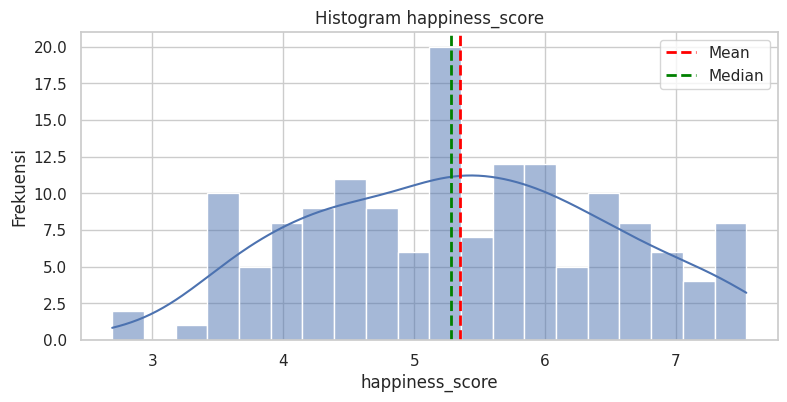

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(x, bins=20, kde=True)
plt.axvline(mean_value, color="red", linestyle="--", linewidth=2, label="Mean")
plt.axvline(median_value, color="green", linestyle="--", linewidth=2, label="Median")
plt.title(f"Histogram {target}")
plt.xlabel(target)
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

## F2. Boxplot


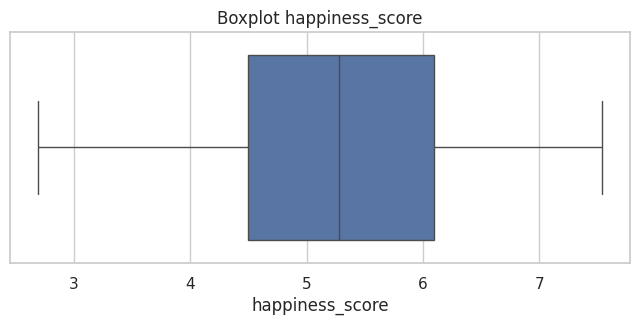

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=x)
plt.title(f"Boxplot {target}")
plt.xlabel(target)
plt.show()

## F3. Rata-rata `happiness_score` per region


,count,mean,median,std,min,max
region,,,,,,
North America,2,7.154500,7.1545,0.228395,6.993,7.316
Western Europe,19,6.880474,6.9510,0.611070,5.195,7.537
Latin America,22,5.957818,6.0395,0.750925,3.603,7.079
Eastern Europe,22,5.513091,5.5900,0.397909,4.644,6.098
Asia-Pacific,43,5.358326,5.2690,0.955062,3.462,7.314
Africa,44,4.239500,4.1850,0.681866,2.693,5.872
Europe,1,4.096000,4.0960,NaN,4.096,4.096


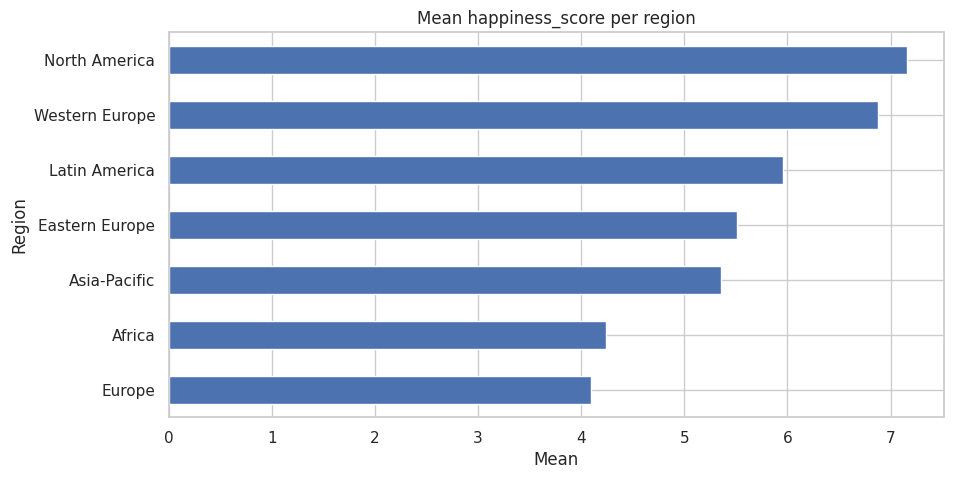

In [ ]:
if "region" in df.columns:
    region_summary = (
        df.groupby("region")[target]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .sort_values("mean", ascending=False)
    )
    display(region_summary)

    plt.figure(figsize=(10, 5))
    region_summary["mean"].sort_values().plot(kind="barh")
    plt.title(f"Mean {target} per region")
    plt.xlabel("Mean")
    plt.ylabel("Region")
    plt.show()
else:
    print("Kolom region tidak tersedia.")

# Bagian G — Interpretasi singkat


In [ ]:
print(f"Mean      : {mean_value:.4f}")
print(f"Median    : {median_value:.4f}")
print(f"Std       : {std_value:.4f}")
print(f"IQR       : {iqr_value:.4f}")
print(f"Skewness  : {skewness_value:.4f}")
print(f"Kurtosis  : {kurtosis_value:.4f}")
print(f"Min       : {x.min():.4f}")
print(f"Q1        : {q1:.4f}")
print(f"Q3        : {q3:.4f}")
print(f"Max       : {x.max():.4f}")


Mean      : 5.3493
Median    : 5.2790
Std       : 1.1350
IQR       : 1.6010
Skewness  : 0.0169
Kurtosis  : -0.7558
Min       : 2.6930
Q1        : 4.4970
Q3        : 6.0980
Max       : 7.5370


## Template jawaban interpretasi mahasiswa

Salin template berikut dan lengkapi dengan bahasa Anda sendiri.

**Paragraf 1 — ukuran pusat**  
Rata-rata (`mean`) variabel `happiness_score` adalah ... sedangkan nilai tengah (`median`) adalah .... Karena mean dan median ... , maka distribusi data dapat dikatakan ....

**Paragraf 2 — ukuran penyebaran**  
Nilai `standard deviation` sebesar ... menunjukkan bahwa data .... Sementara itu, `IQR` sebesar ... berarti 50% data tengah berada pada rentang ....

**Paragraf 3 — bentuk distribusi**  
Nilai `skewness` sebesar ... menunjukkan bahwa distribusi data cenderung .... Nilai `kurtosis` sebesar ... menunjukkan bahwa bentuk distribusi ....

**Paragraf 4 — five-number summary dan outlier**  
Berdasarkan five-number summary, nilai minimum adalah ..., Q1 adalah ..., median adalah ..., Q3 adalah ..., dan maksimum adalah .... Dari aturan 1.5×IQR, terlihat bahwa ....


# Bagian H — Latihan mandiri


## Latihan 1

Ganti variabel utama dari `happiness_score` menjadi:
- `economy`
- `health`
- `freedom`

Lalu bandingkan:
- mean
- median
- standard deviation
- IQR
- skewness
- kurtosis

**Pertanyaan:**  
Variabel mana yang paling bervariasi?  
Variabel mana yang distribusinya paling simetris?


In [ ]:
ekonomi = "economy" if "economy" in df.columns else numeric_cols[0]
a = df[target].dropna()

kesehatan = "health" if "health" in df.columns else numeric_cols[0]
b = df[target].dropna()

kebebasan = "freedom" if "freedom" in df.columns else numeric_cols[0]
c = df[target].dropna()

In [ ]:
print("Variabel utama yang dipakai:", ekonomi, "|", kesehatan, "|", kebebasan)
print("Jumlah data valid:", len(a), "|", len(b), "|", len(c))

Variabel utama yang dipakai: economy | health | freedom
Jumlah data valid: 153 | 153 | 153


In [ ]:
df[[ekonomi, kesehatan, kebebasan]].describe()

# ekonomi paling bervariasi karena stdnya paling besar

,economy,health,freedom
count,153.000000,153.000000,153.000000
mean,0.982433,0.550117,0.408489
std,0.421901,0.237769,0.150744
min,0.000000,0.000000,0.000000
25%,0.659517,0.364509,0.300741
50%,1.064578,0.606042,0.437454
75%,1.315175,0.719217,0.518631
max,1.870766,0.949492,0.658249


In [ ]:
print(f"Median {ekonomi} = {df['economy'].median():.4f}")
print(f"Median {kesehatan} = {df['health'].median():.4f}")
print(f"Median {kebebasan} = {df['freedom'].median():.4f}", "\n")

print("Mode economy:")
print(df['economy'].mode())

if len(df['economy'].mode()) > 0:
    print(f"Mode pertama = {df['economy'].mode().iloc[0]:.4f}", "\n")

print("Mode health:")
print(df['health'].mode())

if len(df['health'].mode()) > 0:
    print(f"Mode pertama = {df['health'].mode().iloc[0]:.4f}", "\n")

print("Mode freedom:")
print(df['freedom'].mode())

if len(df['freedom'].mode()) > 0:
    print(f"Mode pertama = {df['freedom'].mode().iloc[0]:.4f}", "\n")

Median economy = 1.0646
Median health = 0.6060
Median freedom = 0.4375 

Mode economy:
0      0.000000
1      0.022643
2      0.091623
3      0.092102
4      0.119042
         ...   
148    1.626343
149    1.632952
150    1.692278
151    1.741944
152    1.870766
Name: economy, Length: 153, dtype: float64
Mode pertama = 0.0000 

Mode health:
0      0.000000
1      0.005565
2      0.018773
3      0.041135
4      0.048642
         ...   
148    0.888961
149    0.900214
150    0.913476
151    0.943062
152    0.949492
Name: health, Length: 153, dtype: float64
Mode pertama = 0.0000 

Mode freedom:
0      0.000000
1      0.014996
2      0.030370
3      0.059901
4      0.081539
         ...   
148    0.626007
149    0.627163
150    0.633376
151    0.635423
152    0.658249
Name: freedom, Length: 153, dtype: float64
Mode pertama = 0.0000 



## Latihan 2

Buat ringkasan descriptive statistics untuk setiap `region`.

**Petunjuk:**  
Gunakan `groupby("region")`.

Ringkasan yang disarankan:
- mean
- median
- standard deviation
- minimum
- maximum

**Pertanyaan:**  
Apakah ada region yang memiliki rata-rata `happiness_score` lebih tinggi daripada region lain?


## Latihan 3

Pilih satu region, lalu bandingkan distribusi `happiness_score` negara-negara di region tersebut dengan region lain.

Gunakan bantuan:
- histogram
- boxplot
- skewness
- five-number summary

**Pertanyaan:**  
Apakah ada region yang cenderung memiliki skor lebih tinggi?  
Apakah distribusinya simetris atau menceng?


## Aktivitas diskusi kelas


# Bagian I — Tugas Week 5


Gunakan **1 dataset publik** yang Anda pilih sendiri, lalu kerjakan analisis statistika deskriptif dengan tahapan berikut.

## Soal Tugas Week 5

### 1. Jelaskan sumber dataset
Tuliskan informasi berikut:
- **nama dataset**
- **link sumber**
- **periode data**
- **unit analisis**
- **arti variabel utama**

### 2. Muat dataset ke Python
Gunakan `pandas`, lalu tampilkan:
- `shape`
- `head()`
- `info()`
- `describe()`

### 3. Lakukan pemeriksaan kualitas data
Lakukan pengecekan berikut:
- **missing values**
- **data duplikat**
- **nilai yang tidak wajar** pada variabel utama

### 4. Hitung statistik deskriptif
Pilih **minimal 2 variabel numerik**, lalu hitung:
- **mean**
- **median**
- **mode** *(jika relevan)*
- **range**
- **variance**
- **standard deviation**
- **IQR**
- **five-number summary**
- **skewness**
- **kurtosis**
- **outlier** dengan aturan **1.5 × IQR**

### 5. Analisis variabel kategorik
Jika ada variabel kategorik, buat:
- **tabel frekuensi**
- **proporsi**
- **ringkasan numerik per kelompok**

### 6. Tulis interpretasi hasil
Tuliskan interpretasi yang mencakup:
- **bentuk distribusi**
- **penyebaran data**
- **outlier**
- **hubungan antar variabel**
- **rekomendasi ringkasan statistik yang paling sesuai**

### 7. Tulis kesimpulan akhir
Tuliskan **kesimpulan akhir** secara singkat dan jelas.

## Ketentuan pengumpulan
Mahasiswa mengumpulkan:
1. **Notebook** (`.ipynb`) yang berisi seluruh proses analisis.
2. **Laporan singkat** (`.pdf` atau `.docx`) yang memuat ringkasan hasil, visualisasi, interpretasi, dan kesimpulan.
3. **File dataset** yang digunakan, jika ukuran file memungkinkan.

## Format penyusunan notebook
Gunakan urutan berikut agar rapi dan mudah dinilai:
1. Judul tugas  
2. Identitas mahasiswa  
3. Deskripsi dataset  
4. Import library  
5. Load data  
6. Pemeriksaan awal data  
7. Missing values dan duplikasi  
8. Validasi nilai  
9. Statistik deskriptif numerik  
10. Statistik kategorik  
11. Visualisasi  
12. Interpretasi  
13. Kesimpulan


## Rubrik Penilaian Tugas Week 5

| Komponen | Bobot | Sangat Baik (4) | Baik (3) | Cukup (2) | Kurang (1) |
|---|---:|---|---|---|---|
| Pemilihan dataset | 15% | Dataset sesuai syarat, sumber jelas, dan konteks dipahami dengan baik | Dataset cukup sesuai dan sumber jelas | Dataset digunakan tetapi konteks kurang lengkap | Dataset tidak sesuai atau sumber tidak jelas |
| Pemahaman dataset | 15% | Menjelaskan nama data, sumber, periode, unit analisis, dan variabel dengan jelas | Penjelasan cukup jelas, ada sedikit yang kurang lengkap | Penjelasan masih umum dan kurang rinci | Penjelasan sangat minim |
| Pemeriksaan awal data | 10% | `shape`, `head()`, `info()`, dan `describe()` lengkap serta dijelaskan | Semua ditampilkan, penjelasan masih singkat | Hanya sebagian yang ditampilkan | Pemeriksaan awal tidak lengkap |
| Pemeriksaan kualitas data | 15% | Missing values, duplikasi, dan validasi nilai diperiksa lengkap dengan justifikasi | Pemeriksaan cukup lengkap, justifikasi terbatas | Pemeriksaan ada tetapi kurang sistematis | Pemeriksaan sangat minim atau tidak dilakukan |
| Statistik deskriptif numerik | 20% | location, dispersion, five-number summary, skewness, kurtosis, outlier | Sebagian besar benar, ada sedikit kekurangan | Hanya statistik dasar yang dihitung | Banyak perhitungan belum ada atau tidak tepat |
| Statistik kategorik | 10% | Frekuensi, proporsi, dan ringkasan per kelompok lengkap dan tepat | Sebagian besar lengkap | Hanya frekuensi atau proporsi saja | Tidak ada analisis kategorik padahal tersedia |
| Interpretasi hasil | 15% | Interpretasi jelas, logis, dan menghubungkan angka, grafik, serta konteks | Interpretasi cukup baik tetapi belum mendalam | Interpretasi masih sangat deskriptif | Interpretasi tidak jelas atau sangat minim |
| Kerapian penyajian | 10% | Notebook/laporan sangat rapi, sistematis, dan mudah diikuti | Cukup rapi dan terstruktur | Kurang rapi tetapi masih dapat dibaca | Tidak rapi dan sulit diikuti |

**Total: 100%**

### Catatan penilaian
- Notebook tidak cukup hanya berisi kode; setiap hasil penting harus diberi penjelasan.
- Interpretasi harus ditulis dengan bahasa sendiri.
- Kerapian alur pengerjaan juga menjadi bagian dari penilaian.


## Kesimpulan

Pada praktikum ini, dipelajari bahwa descriptive statistics membantu dalam menjawab pertanyaan dasar tentang data secara **terurut dan sistematis**:

- **Di mana pusat data berada?** → mean, median, mode  
- **Seberapa menyebar data?** → range, variance, standard deviation, IQR, coefficient of variation  
- **Di mana posisi data berada?** → quartile dan five-number summary  
- **Bagaimana bentuk distribusinya?** → skewness dan kurtosis  
- **Apakah ada nilai ekstrem?** → deteksi outlier dengan aturan 1.5 × IQR  

Semua ukuran ini saling melengkapi. Karena itu, statistika deskriptif bukan hanya tentang menghitung angka, tetapi juga tentang **membaca cerita dari data** dengan benar.
